### Importation et Configurations 

In [19]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime
import numpy as np

# Configuration des visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Bibliothèques importées")

✅ Bibliothèques importées


### Chargement des Données

In [13]:
# Configuration du chemin
base_path = "../data/raw/smart-building-system"

# Vérification de la structure
print("📁 STRUCTURE DU DATASET :")
building_dirs = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
print(f"Nombre de bâtiments trouvés : {len(building_dirs)}")
print(f"Premiers bâtiments : {building_dirs[:10]}")

📁 STRUCTURE DU DATASET :
Nombre de bâtiments trouvés : 51
Premiers bâtiments : ['413', '415', '417', '419', '421', '422', '423', '424', '442', '446']


### Vérification des Fichiers

In [14]:
# Vérification des fichiers pour un bâtiment exemple
sample_building = building_dirs[0] if building_dirs else None
if sample_building:
    sample_path = os.path.join(base_path, sample_building)
    print(f"📋 FICHIERS DISPONIBLES pour le bâtiment {sample_building}:")
    csv_files = [f for f in os.listdir(sample_path) if f.endswith('.csv')]
    for file in csv_files:
        print(f"  - {file}")

📋 FICHIERS DISPONIBLES pour le bâtiment 413:
  - co2.csv
  - humidity.csv
  - light.csv
  - pir.csv
  - temperature.csv


### Analyse de la Structure

In [15]:
# Fonction pour analyser un type de capteur
def analyze_sensor_type(sensor_type):
    """Analyse un type de capteur spécifique"""
    sensor_data = {}
    
    for building in building_dirs[:3]:  # Analyse les 3 premiers pour l'exemple
        file_path = os.path.join(base_path, building, f"{sensor_type}.csv")
        
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            sensor_data[building] = {
                'shape': df.shape,
                'columns': list(df.columns),
                'sample_data': df.head(2)
            }
    
    return sensor_data

# Analyse des différents capteurs
sensor_types = ['co2', 'humidity', 'light', 'pir', 'temperature']

print("🔍 STRUCTURE DES CAPTEURS :")
for sensor in sensor_types:
    print(f"\n📟 {sensor.upper()} :")
    sensor_info = analyze_sensor_type(sensor)
    if sensor_info:
        first_building = list(sensor_info.keys())[0]
        print(f"   Shape: {sensor_info[first_building]['shape']}")
        print(f"   Colonnes: {sensor_info[first_building]['columns']}")

🔍 STRUCTURE DES CAPTEURS :

📟 CO2 :
   Shape: (130911, 2)
   Colonnes: ['1377299107', ' 488.00']

📟 HUMIDITY :
   Shape: (130859, 2)
   Colonnes: ['1377299107', ' 45.34']

📟 LIGHT :
   Shape: (130859, 2)
   Colonnes: ['1377299107', ' 97.00']

📟 PIR :
   Shape: (72185, 2)
   Colonnes: ['1377299108', ' 0.00']

📟 TEMPERATURE :
   Shape: (130859, 2)
   Colonnes: ['1377299107', ' 23.93']


### Chargement d'un Bâtiment Exemple


In [16]:
# Chargement des données d'un bâtiment spécifique
def load_building_data(building_id):
    """Charge toutes les données d'un bâtiment spécifique"""
    building_path = os.path.join(base_path, building_id)
    building_data = {}
    
    for sensor in sensor_types:
        file_path = os.path.join(building_path, f"{sensor}.csv")
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            # Ajout d'une colonne building_id pour tracer l'origine
            df['building_id'] = building_id
            building_data[sensor] = df
    
    return building_data

# Chargement d'un bâtiment exemple
sample_building_id = building_dirs[0]
sample_data = load_building_data(sample_building_id)

print(f"🏢 DONNÉES DU BÂTIMENT {sample_building_id} :")
for sensor, df in sample_data.items():
    print(f"\n{sensor.upper()}:")
    print(f"  Shape: {df.shape}")
    print(f"  Colonnes: {list(df.columns)}")
    print(f"  Exemple de données:")
    display(df.head(3))

🏢 DONNÉES DU BÂTIMENT 413 :

CO2:
  Shape: (130911, 3)
  Colonnes: ['1377299107', ' 488.00', 'building_id']
  Exemple de données:


,1377299107,488.00,building_id
0,1377299108,495.0,413
1,1377299110,487.0,413
2,1377299127,496.0,413



HUMIDITY:
  Shape: (130859, 3)
  Colonnes: ['1377299107', ' 45.34', 'building_id']
  Exemple de données:


,1377299107,45.34,building_id
0,1377299108,45.34,413
1,1377299126,45.34,413
2,1377299131,45.31,413



LIGHT:
  Shape: (130859, 3)
  Colonnes: ['1377299107', ' 97.00', 'building_id']
  Exemple de données:


,1377299107,97.00,building_id
0,1377299108,97.0,413
1,1377299126,97.0,413
2,1377299131,97.0,413



PIR:
  Shape: (72185, 3)
  Colonnes: ['1377299108', ' 0.00', 'building_id']
  Exemple de données:


,1377299108,0.00,building_id
0,1377299126,0.0,413
1,1377299127,0.0,413
2,1377299130,0.0,413



TEMPERATURE:
  Shape: (130859, 3)
  Colonnes: ['1377299107', ' 23.93', 'building_id']
  Exemple de données:


,1377299107,23.93,building_id
0,1377299108,23.94,413
1,1377299126,23.93,413
2,1377299131,23.93,413


### Analyse de la Qualité des Données

In [17]:
# Analyse des valeurs manquantes et types de données
print("🔍 QUALITÉ DES DONNÉES :")

for sensor, df in sample_data.items():
    print(f"\n📊 {sensor.upper()} :")
    print(f"   Valeurs manquantes: {df.isnull().sum().sum()}")
    print(f"   Types de données:")
    for col in df.columns:
        print(f"     - {col}: {df[col].dtype}")

🔍 QUALITÉ DES DONNÉES :

📊 CO2 :
   Valeurs manquantes: 0
   Types de données:
     - 1377299107: int64
     -  488.00: float64
     - building_id: object

📊 HUMIDITY :
   Valeurs manquantes: 0
   Types de données:
     - 1377299107: int64
     -  45.34: float64
     - building_id: object

📊 LIGHT :
   Valeurs manquantes: 0
   Types de données:
     - 1377299107: int64
     -  97.00: float64
     - building_id: object

📊 PIR :
   Valeurs manquantes: 0
   Types de données:
     - 1377299108: int64
     -  0.00: float64
     - building_id: object

📊 TEMPERATURE :
   Valeurs manquantes: 0
   Types de données:
     - 1377299107: int64
     -  23.93: float64
     - building_id: object


### Analyse Statistique

In [20]:
# Analyse statistique pour les données numériques
print("📈 ANALYSE STATISTIQUE :")

for sensor, df in sample_data.items():
    # Sélectionner uniquement les colonnes numériques
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        print(f"\n{sensor.upper()} - Statistiques:")
        display(df[numeric_cols].describe())

📈 ANALYSE STATISTIQUE :

CO2 - Statistiques:


,1377299107,488.00
count,1.309110e+05,130911.000000
mean,1.377636e+09,485.293566
std,1.974657e+05,58.138536
min,1.377299e+09,415.000000
25%,1.377463e+09,448.000000
50%,1.377627e+09,463.000000
75%,1.377810e+09,487.000000
max,1.377973e+09,768.000000



HUMIDITY - Statistiques:


,1377299107,45.34
count,1.308590e+05,130859.000000
mean,1.377636e+09,49.395187
std,1.974571e+05,2.695169
min,1.377299e+09,42.380000
25%,1.377463e+09,47.860000
50%,1.377626e+09,49.710000
75%,1.377810e+09,51.280000
max,1.377973e+09,54.450000



LIGHT - Statistiques:


,1377299107,97.00
count,1.308590e+05,130859.000000
mean,1.377636e+09,53.662140
std,1.974571e+05,62.448547
min,1.377299e+09,0.000000
25%,1.377463e+09,4.000000
50%,1.377626e+09,9.000000
75%,1.377810e+09,103.000000
max,1.377973e+09,333.000000



PIR - Statistiques:


,1377299108,0.00
count,7.218500e+04,72185.000000
mean,1.377659e+09,0.455843
std,2.077448e+05,3.299504
min,1.377299e+09,0.000000
25%,1.377479e+09,0.000000
50%,1.377659e+09,0.000000
75%,1.377839e+09,0.000000
max,1.378019e+09,30.000000



TEMPERATURE - Statistiques:


,1377299107,23.93
count,1.308590e+05,130859.000000
mean,1.377636e+09,23.944423
std,1.974571e+05,0.753724
min,1.377299e+09,22.630000
25%,1.377463e+09,23.280000
50%,1.377626e+09,23.840000
75%,1.377810e+09,24.510000
max,1.377973e+09,25.650000


### Visualisations

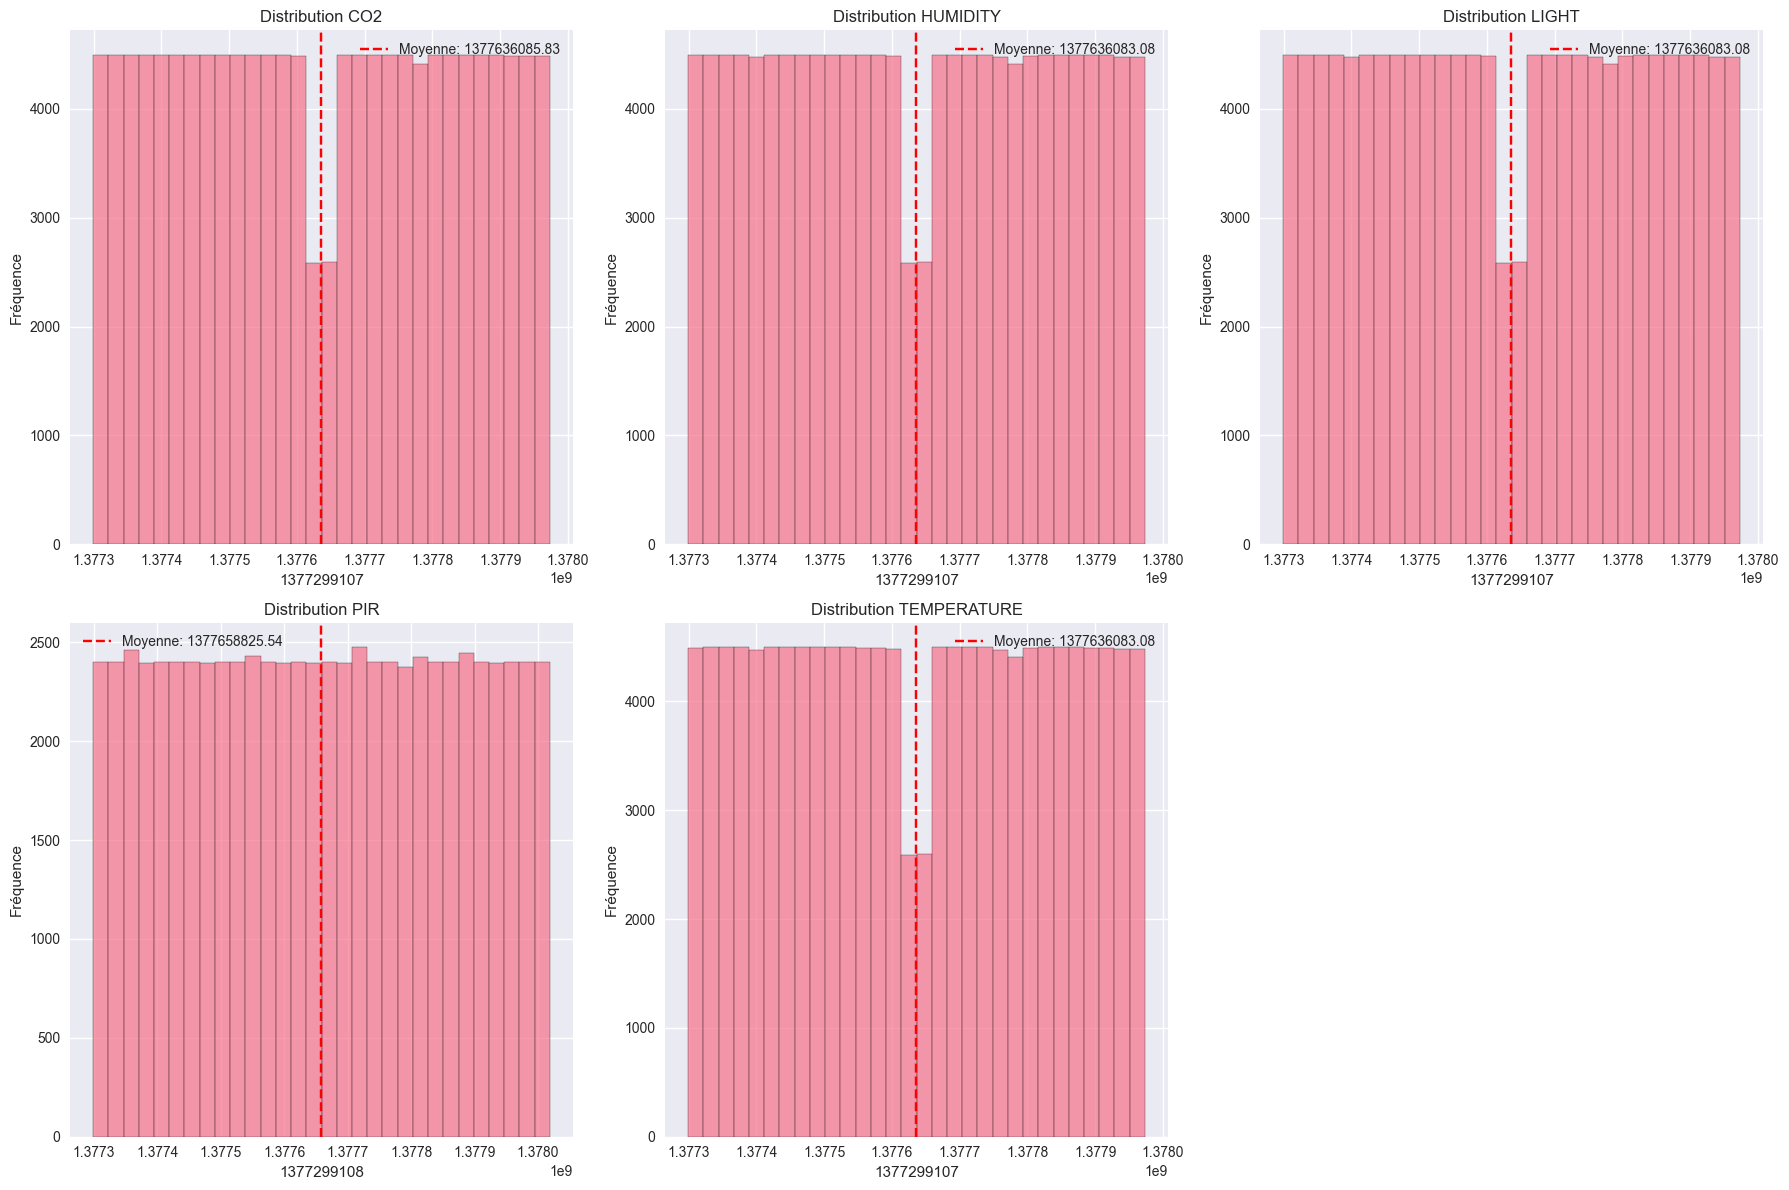

In [21]:
# Visualisations pour chaque type de capteur
def plot_sensor_distributions(building_data):
    """Crée des visualisations pour les données des capteurs"""
    
    # Configuration des subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()
    
    plot_idx = 0
    
    for sensor, df in building_data.items():
        if plot_idx >= len(axes):
            break
            
        # Trouver la première colonne numérique (hors building_id)
        numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                       if col != 'building_id']
        
        if numeric_cols:
            main_col = numeric_cols[0]
            
            # Histogramme
            axes[plot_idx].hist(df[main_col].dropna(), bins=30, alpha=0.7, edgecolor='black')
            axes[plot_idx].set_title(f'Distribution {sensor.upper()}')
            axes[plot_idx].set_xlabel(main_col)
            axes[plot_idx].set_ylabel('Fréquence')
            
            # Ajouter des statistiques
            mean_val = df[main_col].mean()
            axes[plot_idx].axvline(mean_val, color='red', linestyle='--', 
                                 label=f'Moyenne: {mean_val:.2f}')
            axes[plot_idx].legend()
            
            plot_idx += 1
    
    # Cacher les subplots non utilisés
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Générer les visualisations
plot_sensor_distributions(sample_data)